In [ ]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
from scripts.data_visualization import overlay_masks,overlay_boxes
from scripts.converters import convert_boxes_to_xywh
from matplotlib import pyplot as plt
import cv2

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# REFINED [old]: Sam3Model.from_pretrained("facebook/sam3").to(device) → [new]: separated to avoid Pyright misresolving chain return type as str
model: Sam3Model = Sam3Model.from_pretrained("facebook/sam3")
model.to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

In [ ]:
image = cv2.imread("../data/cat.jpg")

inputs = processor(images=Image.fromarray(image), text="ear", return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist()
)[0]



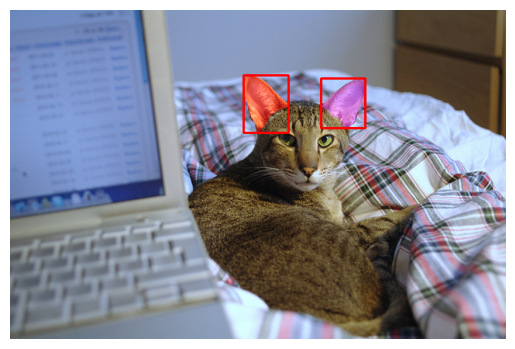

In [13]:
masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())
if image is not None:
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
result = overlay_masks(image, masks)
result = overlay_boxes(result, boxes, color=(255, 0, 0), label="predicted")
plt.imshow(result)
plt.axis("off")
plt.show()